# **Unsupervised Learning**

### **Clustering and Dimensionality Reduction of Global Public Health Indicators Using the WHO Life Expectancy Dataset**

In [26]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

### 1. **Perform preprocessing**

#### **Load and inspect the dataset**

In [5]:
# Load the dataset

life_expectancy_data = pd.read_csv("Life_Expectancy_Data.csv")

In [6]:
# Display the first 5 rows

life_expectancy_data.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [7]:
# Remove leading/trailing spaces from column names
life_expectancy_data.columns = life_expectancy_data.columns.str.strip()

In [8]:
print(life_expectancy_data.info())

<class 'pandas.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   str    
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   str    
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10  BMI                              2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio                          

#### **Handle the missing values**

In [9]:
# Check the missing values
print(life_expectancy_data.isnull().sum())

Country                              0
Year                                 0
Status                               0
Life expectancy                     10
Adult Mortality                     10
infant deaths                        0
Alcohol                            194
percentage expenditure               0
Hepatitis B                        553
Measles                              0
BMI                                 34
under-five deaths                    0
Polio                               19
Total expenditure                  226
Diphtheria                          19
HIV/AIDS                             0
GDP                                448
Population                         652
thinness  1-19 years                34
thinness 5-9 years                  34
Income composition of resources    167
Schooling                          163
dtype: int64


In [10]:
# Fill the missing values in numerical values with median and mode for categorical

numeric_cols = life_expectancy_data.select_dtypes(include=np.number).columns

life_expectancy_data[numeric_cols] = life_expectancy_data[numeric_cols].fillna(
    life_expectancy_data[numeric_cols].median())

In [11]:
life_expectancy_data['Status'] = life_expectancy_data['Status'].fillna(
    life_expectancy_data['Status'].mode()[0])

In [12]:
# Check for duplicates

print("Duplicates:", life_expectancy_data.duplicated().sum())

Duplicates: 0


#### **Handle categorical variables**

In [13]:
country = life_expectancy_data['Country']

In [14]:
year = life_expectancy_data['Year']

In [15]:
# Select numerical features

X = life_expectancy_data.drop(
    columns=['Country', 'Year', 'Status']
).copy()

In [ ]:
life_expectancy_data = pd.get_dummies(
    life_expectancy_data,
    columns=['Status'],
    drop_first=True,
    dtype=int)

In [18]:
 # Standardize features

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns,
    index=X.index)

### **2. Clustering**

#### **K-Mean clustering**

In [ ]:
# use Silhouette Score to determine the clusters

for k in range(2, 6):
    model = KMeans(n_clusters=k, random_state=42)
    labels = model.fit_predict(X_scaled)
    print(k, silhouette_score(X_scaled, labels))

2 0.27366522618873346
3 0.2729605228803744
4 0.22387485086664133
5 0.24246338305035145


In [ ]:
# Calculating at k=2 (Highest score)

kmeans = KMeans(n_clusters=2, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

#### **Hierarchical Clustering**

In [ ]:
# Determine the number of clusters

for k in range(2, 6):
    model = AgglomerativeClustering(n_clusters=k)
    labels = model.fit_predict(X_scaled)
    print(k, silhouette_score(X_scaled, labels))

2 0.26319418777896314
3 0.26252983309643296
4 0.23860261245837386
5 0.24056554053388704


In [25]:
# Predict at 2 clusters
hier_labels = AgglomerativeClustering(
    n_clusters=2).fit_predict(X_scaled)

#### **3. Visualize the clusters with PCA**

In [27]:
# Reduce variables to two dimensions

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

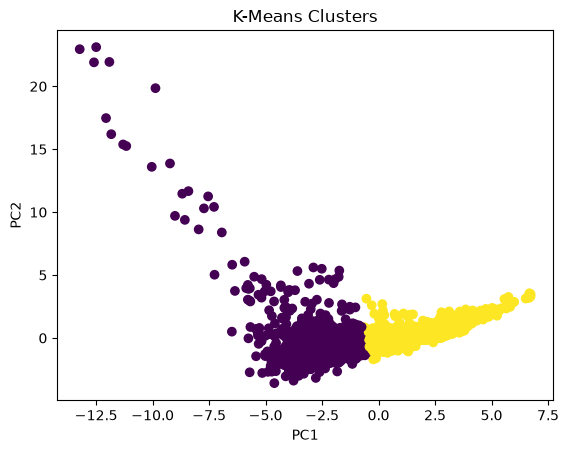

In [28]:
# Visualize K-Means

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clusters")
plt.show()

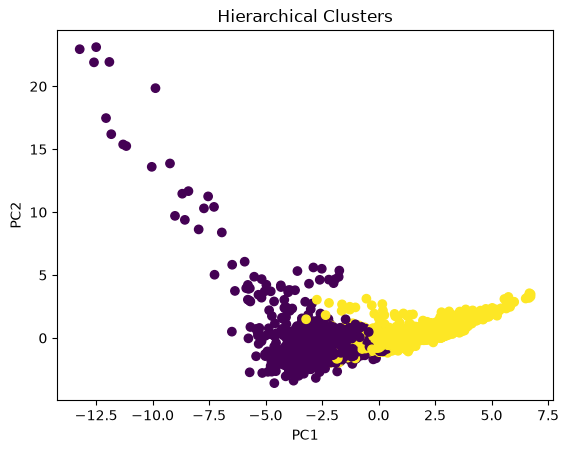

In [29]:
# Visualize Hirearchical clustering

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=hier_labels)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Hierarchical Clusters")
plt.show()

### **4. Model evaluation**

In [ ]:
# Calculate K-Means Silhouette Score

kmeans_score = silhouette_score(X_scaled, kmeans_labels)

print("K-Means Silhouette Score:", round(kmeans_score, 3))

K-Means Silhouette Score: 0.274


In [32]:
# Calculate Hierarchical Clustering Silhouette Score

hier_score = silhouette_score(X_scaled, hier_labels)

print("Hierarchical Silhouette Score:", round(hier_score, 3))

Hierarchical Silhouette Score: 0.263


In [ ]:
# Compare both scores

print("K-Means:", round(kmeans_score, 3))
print("Hierarchical:", round(hier_score, 3))

K-Means: 0.274
Hierarchical: 0.263


#### **Result interpretation**: The K-Means and Hierarchical clustering models were evaluated using the Silhouette Score. K-Means achieved a score of 0.274, while Hierarchical Clustering achieved a score of 0.263. K-Means therefore performed slightly better because it had the higher Silhouette Score. However, both scores are relatively low, indicating that the clusters have some overlap and are not strongly separated. Based on these results, K-Means was selected as the better-performing clustering technique for this dataset.

#### **Deployment and Monitoring**

Since K-Means was the best-performing model with a Silhouette Score of 0.274, 

Deployment scenario:
The K-Means model could be deployed in a public health monitoring system. When new country-level health data become available, such as life expectancy, mortality, immunization, HIV/AIDS, GDP, and schooling indicators, the system could use the trained model to assign observations to one of the identified public-health clusters.

The model should be monitored whenever new data are added. The Silhouette Score can be recalculated to determine whether the clusters remain meaningful. Analysts should also monitor changes in cluster sizes and characteristics and check the quality of incoming data.